<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_oscillation_clock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D9_OSCILLATION_CLOCK

STATE: OSCILLATING
peaks detected: 22
mean period: 73.33
amplitude: 0.234
max activation: 0.462
final activation: 0.347


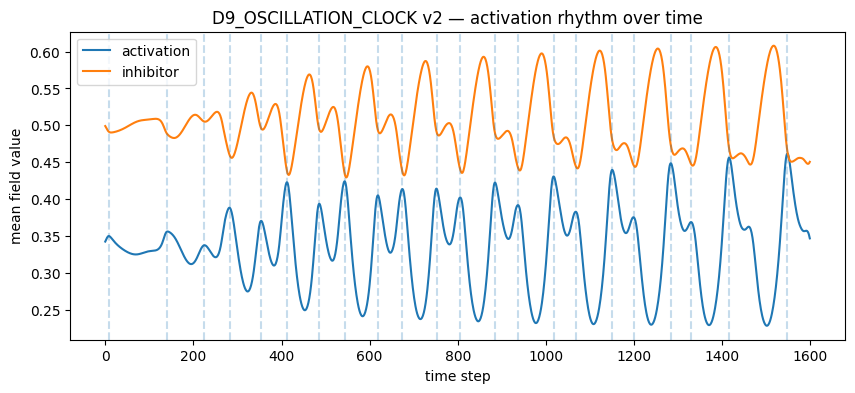

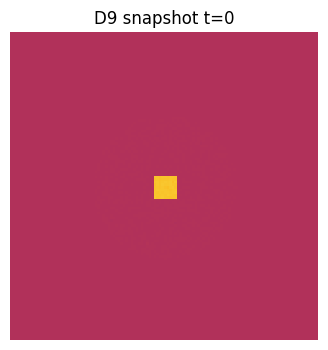

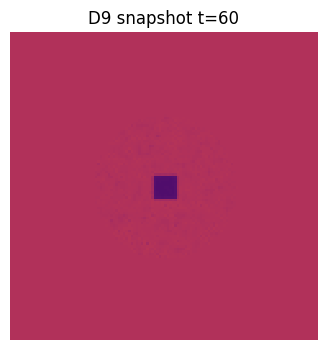

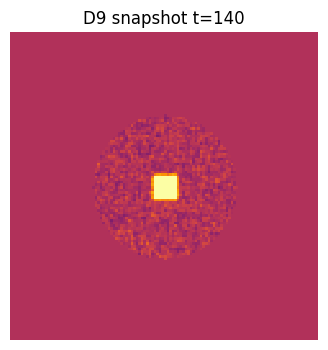

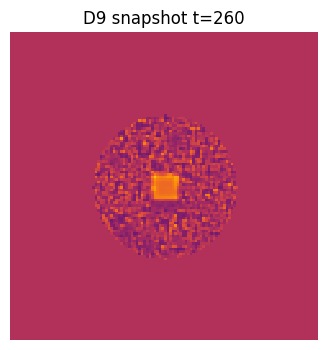

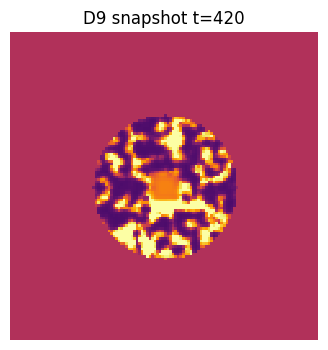

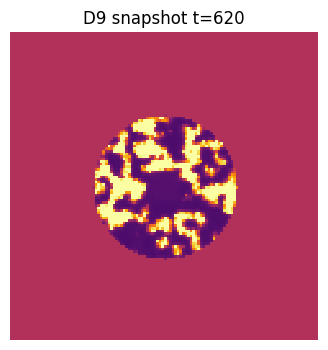

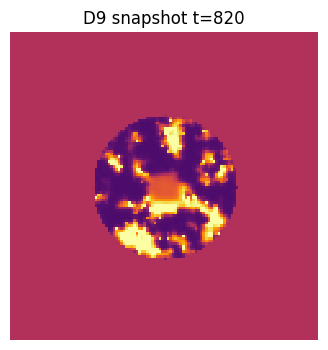

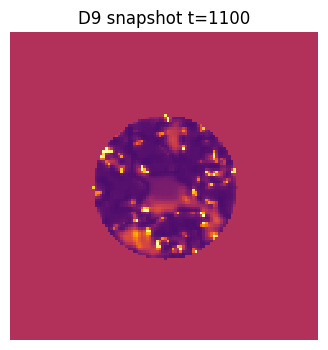

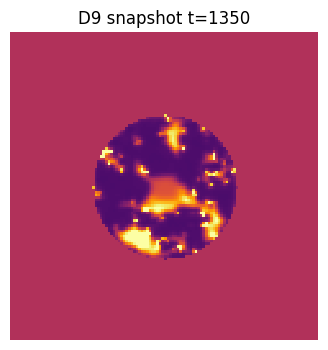

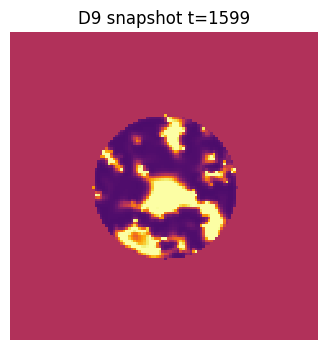

,STATE,RESULT,PEAKS,MEAN_PERIOD,AMPLITUDE,MAX_ACTIVATION,FINAL_ACTIVATION,MAX_INHIBITOR
0,D9_OSCILLATION_CLOCK,OSCILLATING,22,73.33,0.234,0.462,0.347,0.608


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def laplacian(Z):
    return (
        -4 * Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    )


def generate_cell_mask(size=120, radius=28):
    Y, X = np.ogrid[:size, :size]
    c = size // 2

    dist = np.sqrt((X - c) ** 2 + (Y - c) ** 2)

    cell = dist <= radius
    wall = (dist > radius) & (dist <= radius + 2)

    return cell, wall


def find_peaks(signal, threshold=0.28, min_distance=45):
    peaks = []

    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i - 1] and signal[i] > signal[i + 1] and signal[i] > threshold:
            if not peaks or i - peaks[-1] >= min_distance:
                peaks.append(i)

    return peaks


def run_oscillation_clock_v2(
    size=120,
    radius=28,
    steps=1600,
    dt=0.05,
    diffusion_u=0.05,
    diffusion_v=0.02,
    feed_a=1.0,
    feed_b=2.5,
):
    """
    D9_OSCILLATION_CLOCK v2

    This uses a bounded Brusselator-like reaction-diffusion oscillator.

    U = activation field
    V = inhibitor / recovery field

    The cell receives continuous feed.
    This prevents one-shot decay and allows repeated oscillation.
    """

    cell, wall = generate_cell_mask(size=size, radius=radius)

    U = np.ones((size, size), dtype=float) * feed_a
    V = np.ones((size, size), dtype=float) * (feed_b / feed_a)

    rng = np.random.default_rng(7)
    V += 0.05 * rng.normal(size=(size, size))

    c = size // 2

    # Initial pulse in the center
    U[c - 4:c + 5, c - 4:c + 5] += 0.7

    history = []
    snapshots = {}

    for t in range(steps):
        LU = laplacian(U)
        LV = laplacian(V)

        # Brusselator-style reaction:
        # U grows from feed, reacts with V, then is consumed.
        reaction_u = feed_a + (U * U * V) - (feed_b + 1.0) * U
        reaction_v = feed_b * U - (U * U * V)

        U = U + dt * (diffusion_u * LU + reaction_u)
        V = V + dt * (diffusion_v * LV + reaction_v)

        U = np.clip(U, 0, 5)
        V = np.clip(V, 0, 5)

        # Keep oscillator inside bounded cell
        U[~cell] = feed_a
        V[~cell] = feed_b / feed_a

        # Boundary behaves like a damped wall
        U[wall] = feed_a
        V[wall] = feed_b / feed_a

        # Convert U into visible activation 0..1
        activation = np.clip(U / 3.0, 0, 1)

        mean_activation = float(activation[cell].mean())
        max_activation = float(activation[cell].max())
        mean_inhibitor = float((V[cell] / 5.0).mean())

        history.append({
            "t": t,
            "activation_mean": mean_activation,
            "activation_max": max_activation,
            "inhibitor_mean": mean_inhibitor,
        })

        if t in [0, 60, 140, 260, 420, 620, 820, 1100, 1350, steps - 1]:
            snapshots[t] = activation.copy()

    history = pd.DataFrame(history)

    signal = history["activation_mean"].values
    peaks = find_peaks(signal, threshold=0.28, min_distance=45)

    amplitude = float(signal.max() - signal.min())

    if len(peaks) >= 3 and amplitude > 0.05:
        result = "OSCILLATING"
    elif signal[-1] > 0.25:
        result = "STABLE_HIGH"
    elif signal[-1] < 0.10:
        result = "DECAY"
    else:
        result = "LOW_ACTIVITY"

    peak_periods = []
    for i in range(1, len(peaks)):
        peak_periods.append(peaks[i] - peaks[i - 1])

    mean_period = float(np.mean(peak_periods)) if peak_periods else 0.0

    return {
        "U": U,
        "V": V,
        "cell": cell,
        "wall": wall,
        "history": history,
        "snapshots": snapshots,
        "peaks": peaks,
        "result": result,
        "amplitude": amplitude,
        "mean_period": mean_period,
    }


result = run_oscillation_clock_v2()

history = result["history"]
snapshots = result["snapshots"]
peaks = result["peaks"]

print("STATE:", result["result"])
print("peaks detected:", len(peaks))
print("mean period:", round(result["mean_period"], 2))
print("amplitude:", round(result["amplitude"], 3))
print("max activation:", round(float(history["activation_mean"].max()), 3))
print("final activation:", round(float(history["activation_mean"].iloc[-1]), 3))

plt.figure(figsize=(10, 4))
plt.plot(history["t"], history["activation_mean"], label="activation")
plt.plot(history["t"], history["inhibitor_mean"], label="inhibitor")

for p in peaks:
    plt.axvline(p, linestyle="--", alpha=0.25)

plt.title("D9_OSCILLATION_CLOCK v2 — activation rhythm over time")
plt.xlabel("time step")
plt.ylabel("mean field value")
plt.legend()
plt.show()

for t, snap in snapshots.items():
    plt.figure(figsize=(4, 4))
    plt.imshow(snap, cmap="inferno", vmin=0, vmax=0.7, interpolation="nearest")
    plt.title(f"D9 snapshot t={t}")
    plt.axis("off")
    plt.show()

summary = pd.DataFrame([{
    "STATE": "D9_OSCILLATION_CLOCK",
    "RESULT": result["result"],
    "PEAKS": len(peaks),
    "MEAN_PERIOD": round(result["mean_period"], 2),
    "AMPLITUDE": round(result["amplitude"], 3),
    "MAX_ACTIVATION": round(float(history["activation_mean"].max()), 3),
    "FINAL_ACTIVATION": round(float(history["activation_mean"].iloc[-1]), 3),
    "MAX_INHIBITOR": round(float(history["inhibitor_mean"].max()), 3),
}])

summary